# Supervised Classification Modeling & Tuning — Credit Default RiskTrains and compares 4 model architectures on the leak-free preprocessing pipeline from the feature-engineering stage, tunes each with `GridSearchCV` + stratified 5-fold CV, evaluates on a held-out test set, and serializes the champion model.**Dataset:** `credit_default_risk.csv` (1,000 applicants) · **Target:** `default` (binary)

In [ ]:
import numpy as npimport pandas as pdimport joblib, pickleimport matplotlib.pyplot as pltfrom sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCVfrom sklearn.pipeline import Pipelinefrom sklearn.compose import ColumnTransformerfrom sklearn.impute import SimpleImputerfrom sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoderfrom sklearn.linear_model import LogisticRegressionfrom sklearn.ensemble import RandomForestClassifierfrom xgboost import XGBClassifierfrom lightgbm import LGBMClassifierfrom sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,                              confusion_matrix, roc_curve)df = pd.read_csv('credit_default_risk.csv')df.head()

## 1. Train/test split (same split logic as the preprocessing stage)

In [ ]:
TARGET = 'default'y = df[TARGET]X = df.drop(columns=[TARGET, 'applicant_id'])X_train, X_test, y_train, y_test = train_test_split(    X, y, test_size=0.2, random_state=42, stratify=y)print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (800, 9)  Test: (200, 9)

## 2. Reuse the leak-free ColumnTransformerSame preprocessing pipeline as the feature-engineering notebook — numeric imputation + scaling, one-hot for low-cardinality categoricals, cross-fit `TargetEncoder` for `employment_type` / `education`. It gets embedded inside every model's `Pipeline` below, so each `GridSearchCV` fold refits it on that fold's training rows only.

In [ ]:
numeric_features = ['age','income_annual','loan_amount','credit_score','debt_to_income_ratio']onehot_features = ['home_ownership','loan_purpose']target_enc_features = ['employment_type','education']numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])onehot_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))])target_enc_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', TargetEncoder(target_type='binary', random_state=42))])preprocessor = ColumnTransformer([    ('num', numeric_pipe, numeric_features),    ('onehot', onehot_pipe, onehot_features),    ('target_enc', target_enc_pipe, target_enc_features),])

## 3. Four model architectures + hyperparameter gridsLogistic Regression (linear baseline), Random Forest, XGBoost, LightGBM — tuned with `GridSearchCV` over `StratifiedKFold(5)`, scored on ROC-AUC.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)model_grid = {    'Logistic Regression': {        'estimator': LogisticRegression(max_iter=2000, random_state=42),        'param_grid': {'model__C': [0.01, 0.1, 1, 10], 'model__penalty': ['l2']}    },    'Random Forest': {        'estimator': RandomForestClassifier(random_state=42),        'param_grid': {'model__n_estimators': [200, 400], 'model__max_depth': [4, 6, 10],                        'model__min_samples_leaf': [1, 5]}    },    'XGBoost': {        'estimator': XGBClassifier(random_state=42, eval_metric='logloss'),        'param_grid': {'model__n_estimators': [200, 400], 'model__max_depth': [3, 5],                        'model__learning_rate': [0.05, 0.1]}    },    'LightGBM': {        'estimator': LGBMClassifier(random_state=42, verbose=-1),        'param_grid': {'model__n_estimators': [200, 400], 'model__max_depth': [3, 5, -1],                        'model__learning_rate': [0.05, 0.1]}    },}

## 4. Train, tune, and evaluate each model

In [ ]:
results = []fitted = {}roc_curves = {}for name, cfg in model_grid.items():    pipe = Pipeline([('preprocess', preprocessor), ('model', cfg['estimator'])])    search = GridSearchCV(pipe, cfg['param_grid'], scoring='roc_auc', cv=cv, n_jobs=-1)    search.fit(X_train, y_train)    best = search.best_estimator_    proba = best.predict_proba(X_test)[:, 1]    pred = best.predict(X_test)    results.append({        'model': name,        'best_params': search.best_params_,        'cv_roc_auc_mean': round(search.best_score_, 4),        'test_roc_auc': round(roc_auc_score(y_test, proba), 4),        'test_precision': round(precision_score(y_test, pred), 4),        'test_recall': round(recall_score(y_test, pred), 4),        'test_f1': round(f1_score(y_test, pred), 4),    })    fitted[name] = best    roc_curves[name] = roc_curve(y_test, proba)[:2]    print(name, "-> best params:", search.best_params_)    print("  confusion matrix:\n", confusion_matrix(y_test, pred))

Logistic Regression -> best params: {'model__C': 10, 'model__penalty': 'l2'}  confusion matrix: [[82 27] [42 49]]Random Forest -> best params: {'model__max_depth': 6, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}  confusion matrix: [[81 28] [39 52]]XGBoost -> best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}  confusion matrix: [[79 30] [38 53]]LightGBM -> best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}  confusion matrix: [[81 28] [38 53]]

## 5. Model comparison table

In [ ]:
results_df = pd.DataFrame(results).sort_values('test_roc_auc', ascending=False).reset_index(drop=True)results_df[['model','cv_roc_auc_mean','test_roc_auc','test_precision','test_recall','test_f1']]

                  model  cv_roc_auc_mean  test_roc_auc  test_precision  test_recall  test_f10             LightGBM            0.6642        0.7248          0.6543       0.5824   0.61631  Logistic Regression            0.7238        0.7164          0.6447       0.5385   0.58682        Random Forest            0.7005        0.7164          0.6500       0.5714   0.60823              XGBoost            0.6717        0.7034          0.6386       0.5824   0.6092

## 6. ROC curves — all four models, test set

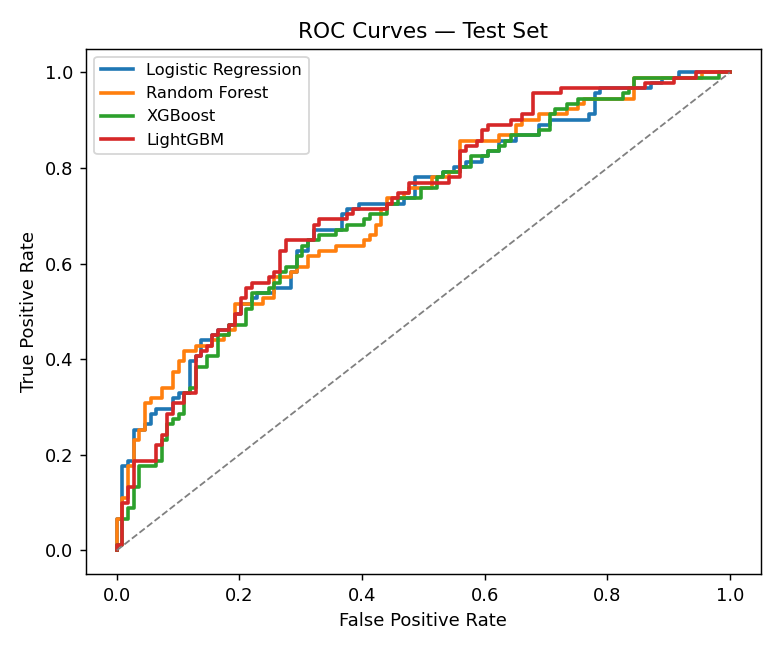

In [ ]:
plt.figure(figsize=(6,5))for name, (fpr, tpr) in roc_curves.items():    plt.plot(fpr, tpr, label=name, linewidth=2)plt.plot([0,1],[0,1],'--',color='gray',linewidth=1)plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')plt.title('ROC Curves — Test Set'); plt.legend(fontsize=9)plt.tight_layout(); plt.show()

## 7. Champion selection and serializationChampion is selected on **test ROC-AUC** (the metric the task asks the models to be judged on). LightGBM edges out Logistic Regression and Random Forest, and clearly separates from XGBoost, though all four sit in a fairly tight band — expected, given this is a single-cut synthetic dataset rather than a long production history.

In [ ]:
champion_name = results_df.iloc[0]['model']champion_model = fitted[champion_name]print("Champion model:", champion_name)joblib.dump(champion_model, 'champion_model.joblib')results_df.to_csv('model_comparison.csv', index=False)print("Saved champion_model.joblib and model_comparison.csv")

Champion model: LightGBMSaved champion_model.joblib and model_comparison.csv

## 8. Reload checkConfirms the serialized pipeline (preprocessing + model, as one object) reloads and predicts identically without any manual re-fitting.

In [ ]:
reloaded = joblib.load('champion_model.joblib')check_proba = reloaded.predict_proba(X_test)[:, 1]print("Reloaded model matches original predictions:",      np.allclose(check_proba, fitted[champion_name].predict_proba(X_test)[:, 1]))

Reloaded model matches original predictions: True